In [2]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker

In [3]:
workspace_base_path = lambda item: os.path.join('/checkpoint/maui/zhaobc/scientist/workspace', item)


In [4]:
ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
    ]
)

Found 42 directories


In [5]:
folder_info = ori_results

r1_bon_dummy_no_knowledge_l1 = []
o3_bon_dummy_no_knowledge_l1 = []
r1_aide_dummy_no_knowledge_l1 = []
o3_aide_dummy_no_knowledge_l1 = []

# print o3, bon, dummy ideator, coder no knowledge
for folder_name, info in folder_info.items():
    if info['model'] == 'o3-mini':
        if info['runner'] == 'bon':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    print(f"{folder_name}: o3, bon, dummy, coder nok")
                    o3_bon_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
# print r1, aide, dummy ideator, coder no knowledge
for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'bon':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    print(f"{folder_name}: r1, bon, dummy, coder nok")
                    r1_bon_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
for folder_name, info in folder_info.items():
    if info['model'] == 'o3-mini':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    print(f"{folder_name}: o3, aide, dummy, coder nok")
                    o3_aide_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 1:
                    print(f"{folder_name}: r1, aide, dummy, coder nok")
                    r1_aide_dummy_no_knowledge_l1.append(folder_name)

record_6_20250408_155217_1747668-1747662-5: o3, bon, dummy, coder nok
record_11_20250408_155217_1747662-1747662-10: o3, bon, dummy, coder nok
record_1_20250408_155217_1747663-1747662-0: o3, bon, dummy, coder nok
record_4_20250408_155217_1747666-1747662-3: o3, bon, dummy, coder nok
record_3_20250408_155217_1747665-1747662-2: o3, bon, dummy, coder nok
record_9_20250408_155217_1747671-1747662-8: o3, bon, dummy, coder nok
record_2_20250408_155217_1747664-1747662-1: o3, bon, dummy, coder nok
record_10_20250408_155217_1747672-1747662-9: o3, bon, dummy, coder nok
record_8_20250408_155217_1747670-1747662-7: o3, bon, dummy, coder nok
record_7_20250408_155217_1747669-1747662-6: o3, bon, dummy, coder nok
record_5_20250408_155217_1747667-1747662-4: o3, bon, dummy, coder nok
--------------------
record_1_20250408_155151_1747652-1747651-0: r1, bon, dummy, coder nok
record_3_20250408_155151_1747654-1747651-2: r1, bon, dummy, coder nok
record_8_20250408_155151_1747659-1747651-7: r1, bon, dummy, coder 

In [6]:
r1_bon_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_bon_dummy_no_knowledge_l1}
o3_bon_dummy_no_knowledge_l1 = {k: folder_info[k] for k in o3_bon_dummy_no_knowledge_l1}
r1_aide_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_aide_dummy_no_knowledge_l1}
o3_aide_dummy_no_knowledge_l1 = {k: folder_info[k] for k in o3_aide_dummy_no_knowledge_l1}




In [21]:
r1_bon_dummy_no_knowledge_l1

{'record_1_20250408_155151_1747652-1747651-0': {'record': 1,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'metrics':     step   val_loss  train_time
  0      0   3.276600   2936369.0
  1      1        NaN         NaN
  2      2   3.276089   2385559.0
  3      3  10.836400         NaN
  4      4  10.826900         NaN
  5      5   3.370800         NaN
  6      6   3.314482         NaN
  7      7   3.380693         NaN
  8      8   3.361304         NaN
  9      9   3.300416         NaN
  10    10   3.355051         NaN
  11    11   3.343294         NaN
  12    12   3.352853         NaN
  13    13   3.351100         NaN
  14    14   3.348140         NaN
  15    15   3.351883         NaN
  16    16   3.352488         NaN
  17    17   3.352422         NaN
  18    18   3.359121         NaN
  19    19   3.363200         NaN
  20    20   3.367905         NaN
  21    21   3.352900         NaN
  22    22   3.351900         NaN


In [15]:
def process_metrics(record):
    for k, v in record.items():
        metrics = gather_metrics(
            workspace_base_path(k),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{v['record']}"
            )
        )
        metrics.loc[metrics['val_loss'] >= 3.29, 'train_time'] = np.nan
        record[k]['metrics'] = metrics
    return record


In [16]:
r1_bon_dummy_no_knowledge_l1 = process_metrics(r1_bon_dummy_no_knowledge_l1)
o3_bon_dummy_no_knowledge_l1 = process_metrics(o3_bon_dummy_no_knowledge_l1)
r1_aide_dummy_no_knowledge_l1 = process_metrics(r1_aide_dummy_no_knowledge_l1)
o3_aide_dummy_no_knowledge_l1 = process_metrics(o3_aide_dummy_no_knowledge_l1)

In [ ]:
def convert_to_dict(record):
    results = {}
    for k, v in record.items():
        record_num = k.split('-')[-1]
        results[int(record_num) + 1] = v['metrics']['train_time'].min()
    return results

r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

In [22]:
r1_bon_results

{1: 2354216.0,
 3: 1282839.0,
 8: 662205.0,
 4: 1288911.0,
 6: 766039.0,
 10: 477150.0,
 2: 1667376.0,
 5: 767420.0,
 7: 720216.0,
 9: 482356.0}

In [10]:

human_train_time_dict = {
    1: 2936369,
    2: 2304681,
    3: 1282839,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839
}

In [11]:
def compute_gap_in_percentage(
        model_time, 
        human_time=human_train_time_dict, 
    ):
    gaps = {}
    for k, v in human_time.items():
        if (k + 1) not in human_time:
            continue
        gaps[k] = v - human_time[k+1]
    
    recovered_times = {}
    for k, v in model_time.items():
        recovered_time = human_time[k] - v
        recovered_times[k] = recovered_time

    recovered_gap_in_percentage = {}
    for k, v in recovered_times.items():
        if (k + 1) not in gaps:
            continue
        recovered_gap_in_percentage[k] = v / gaps[k] if gaps[k] > 0 else 0

    return recovered_gap_in_percentage



In [18]:
r1_bon_gap_in_percentage = compute_gap_in_percentage(r1_bon_results)
r1_aide_gap_in_percentage = compute_gap_in_percentage(r1_aide_results)
o3_bon_gap_in_percentage = compute_gap_in_percentage(o3_bon_results)
o3_aide_gap_in_percentage = compute_gap_in_percentage(o3_aide_results)


In [19]:
o3_bon_gap_in_percentage[3] = 0 # remove this because the summarizer somehow made a mistake here

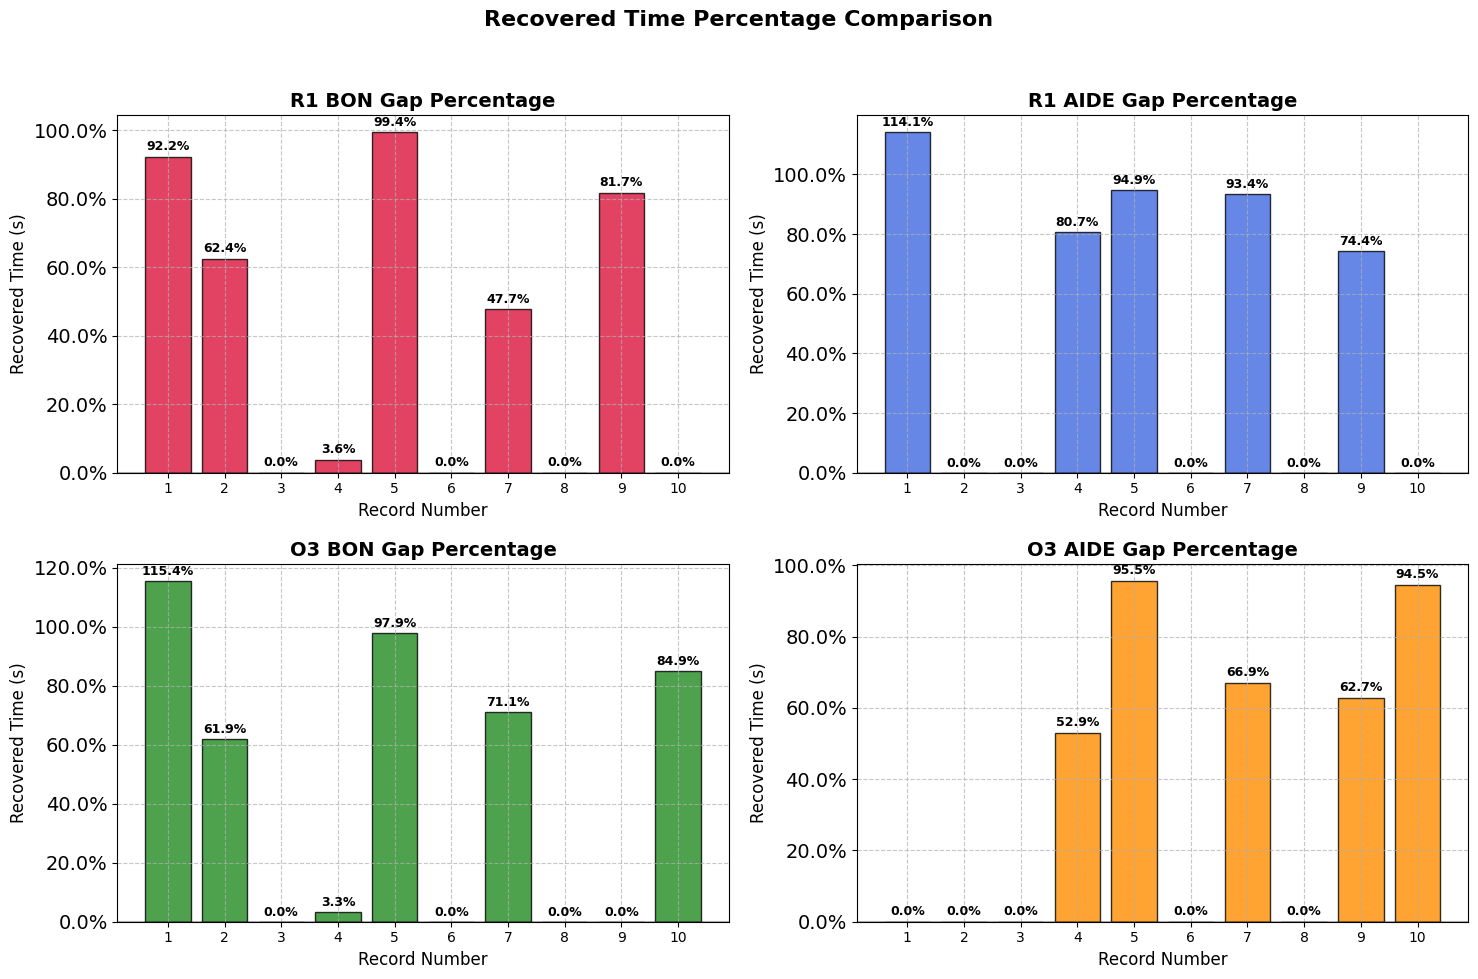

In [14]:
# Create a list of dictionaries and their titles with different colors
data_dicts = [
    (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
    (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
    (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
    (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')
]

# Create a 2x2 subplot layout
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten()  # Flatten the 2x2 array to make indexing easier

# Create a barplot for each dictionary
for i, (data_dict, title, color) in enumerate(data_dicts):
    # Sort the dictionary by keys
    sorted_items = sorted(data_dict.items())
    keys = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]
    
    # Create the barplot with the specified color
    bars = axs[i].bar(keys, values, color=color, edgecolor='black', alpha=0.8)
    
    # Add title and labels
    axs[i].set_title(title, fontsize=14, fontweight='bold')
    axs[i].set_xlabel('Record Number', fontsize=12)
    axs[i].set_ylabel('Recovered Time (s)', fontsize=12)
    
    # Ensure all xticks are shown
    axs[i].set_xticks(keys)
    axs[i].set_xticklabels(keys, fontsize=10)
    
    # Add grid for better readability
    axs[i].grid(True, linestyle='--', alpha=0.7)
    
    # Add a horizontal line at y=0
    axs[i].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Format y-axis as percentage
    axs[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    
    # Annotate the values on top of the bars
    for bar in bars:
        height = bar.get_height()
        if height >= 0:
            y_pos = height + 0.02
        else:
            y_pos = height - 0.05
        axs[i].text(
            bar.get_x() + bar.get_width()/2.,
            y_pos,
            '{:.1%}'.format(height),
            ha='center', 
            fontsize=9,
            fontweight='bold',
            color='black'
        )

# Add a main title for the figure
fig.suptitle('Recovered Time Percentage Comparison', fontsize=16, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for the suptitle

# Show the plot
plt.show()

In [15]:
r1_aide_results[1]

2228680.0

In [16]:
human_train_time_dict[2]

2304681

In [17]:
o3_bon_results[1]

2207229.0

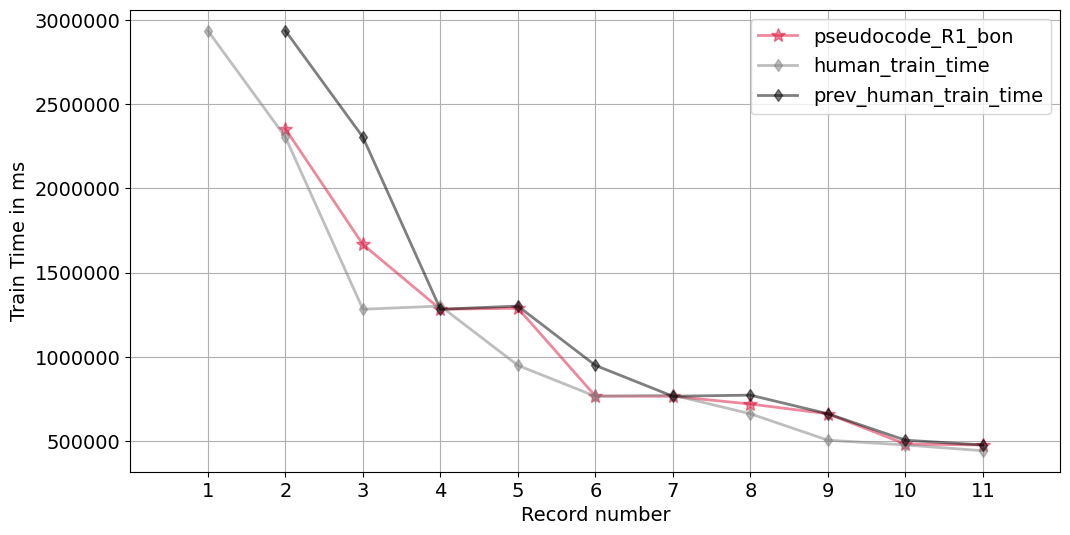

In [60]:
cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots()
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items()}

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

# (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
# (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
# (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
# (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')


r1_bon_results_for_plot = {k + 1: v for k, v in sorted(r1_bon_results.items())}
# sorted_r1_bon_results = {k: v for k, v in sorted(r1_bon_results.items())}
ax.plot(r1_bon_results_for_plot.keys(), 
    r1_bon_results_for_plot.values(), 
    label='pseudocode_R1_bon', 
    color='crimson', linestyle='-', marker='*', markersize=10, linewidth=2, alpha=0.5)
ax.set_xlim(0, 12)
ax.set_xticks(range(1, 12))
ax.plot({k: v for k, v in human_train_time_dict.items() if 1 <= k <= 11}.keys(), 
    {k: v for k, v in human_train_time_dict.items() if 1 <= k <= 11}.values(), 
    label='human_train_time', 
    color=cmap(7), linestyle='-', marker='d', linewidth=2, alpha=0.5)
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items() if 2 <= k + 1 <= 11}
ax.plot(prev_human_train_time_dict.keys(), prev_human_train_time_dict.values(), 
    label='prev_human_train_time', 
    color='black', linestyle='-', marker='d', linewidth=2, alpha=0.5)
ax.set_xlabel('Record number')
ax.set_ylabel('Train Time in ms')
ax.grid()
ax.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.show()

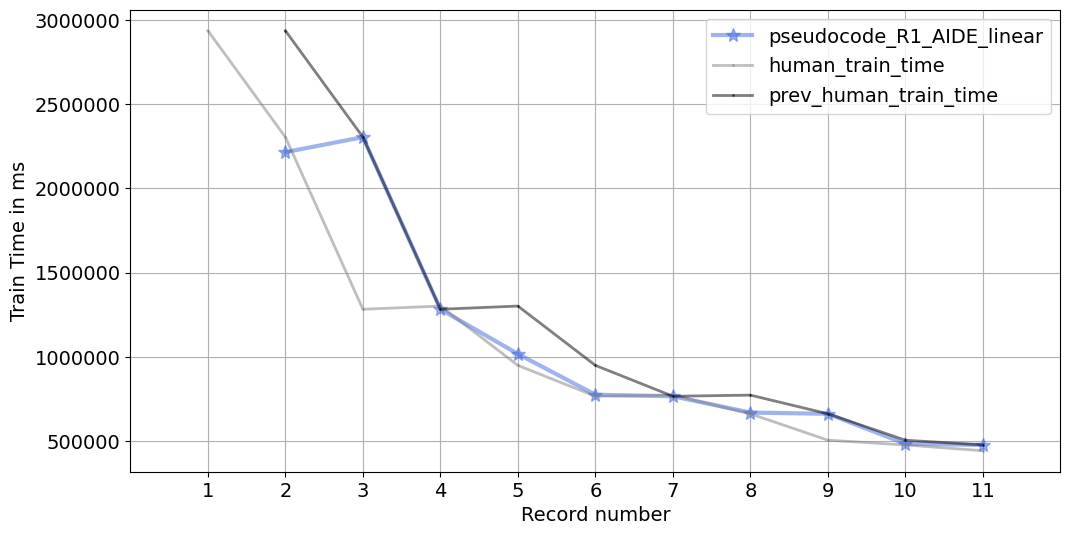

In [64]:
cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots()
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items()}

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

# (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
# (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
# (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
# (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')


r1_aide_results_for_plot = {k + 1: v for k, v in sorted(r1_aide_results.items())}
# sorted_r1_bon_results = {k: v for k, v in sorted(r1_bon_results.items())}
ax.plot(r1_aide_results_for_plot.keys(), 
    r1_aide_results_for_plot.values(), 
    label='pseudocode_R1_AIDE_linear', 
    color='royalblue', linestyle='-', marker='*', markersize=10, linewidth=3, alpha=0.5)
ax.set_xlim(0, 12)
ax.set_xticks(range(1, 12))
ax.plot({k: v for k, v in human_train_time_dict.items() if 1 <= k <= 11}.keys(), 
    {k: v for k, v in human_train_time_dict.items() if 1 <= k <= 11}.values(), 
    label='human_train_time', 
    color=cmap(7), linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items() if 2 <= k + 1 <= 11}
ax.plot(prev_human_train_time_dict.keys(), prev_human_train_time_dict.values(), 
    label='prev_human_train_time', 
    color='black', linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
ax.set_xlabel('Record number')
ax.set_ylabel('Train Time in ms')
ax.grid()
ax.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.show()

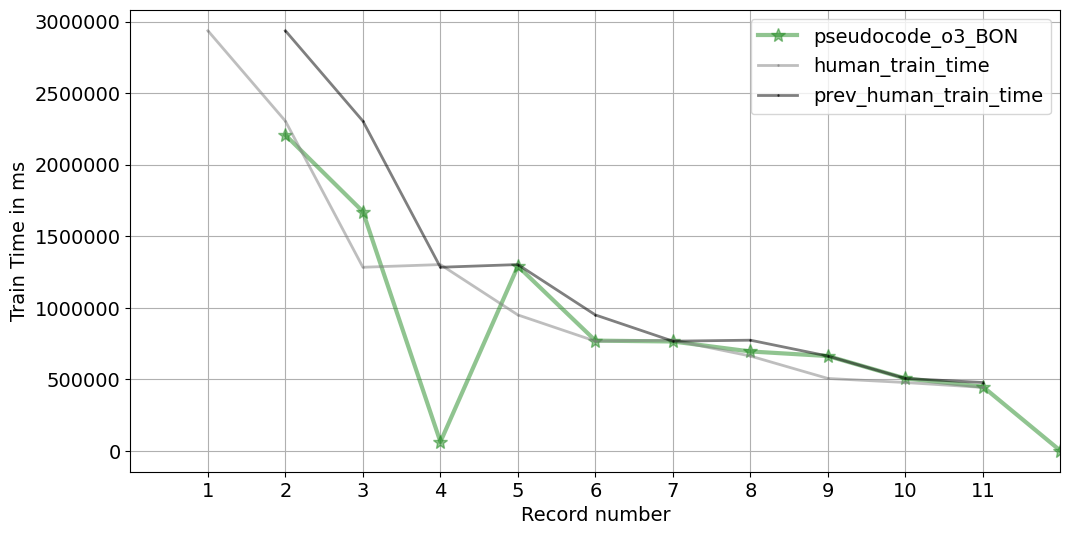

In [74]:
cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots()
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items()}

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

# (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
# (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
# (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
# (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')


o3_bon_results_for_plot = {k + 1: v for k, v in sorted(o3_bon_results.items())}
# sorted_r1_bon_results = {k: v for k, v in sorted(r1_bon_results.items())}
ax.plot(o3_bon_results_for_plot.keys(), 
    o3_bon_results_for_plot.values(), 
    label='pseudocode_o3_BON', 
    color='forestgreen', linestyle='-', marker='*', markersize=10, linewidth=3, alpha=0.5)
ax.set_xlim(0, 12)
ax.set_xticks(range(1, 12))
ax.plot({k: v for k, v in human_train_time_dict.items() if 1 <= k <= 11}.keys(), 
    {k: v for k, v in human_train_time_dict.items() if 1 <= k <= 11}.values(), 
    label='human_train_time', 
    color=cmap(7), linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items() if 2 <= k + 1 <= 11}
ax.plot(prev_human_train_time_dict.keys(), prev_human_train_time_dict.values(), 
    label='prev_human_train_time', 
    color='black', linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
ax.set_xlabel('Record number')
ax.set_ylabel('Train Time in ms')
ax.grid()
ax.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.show()

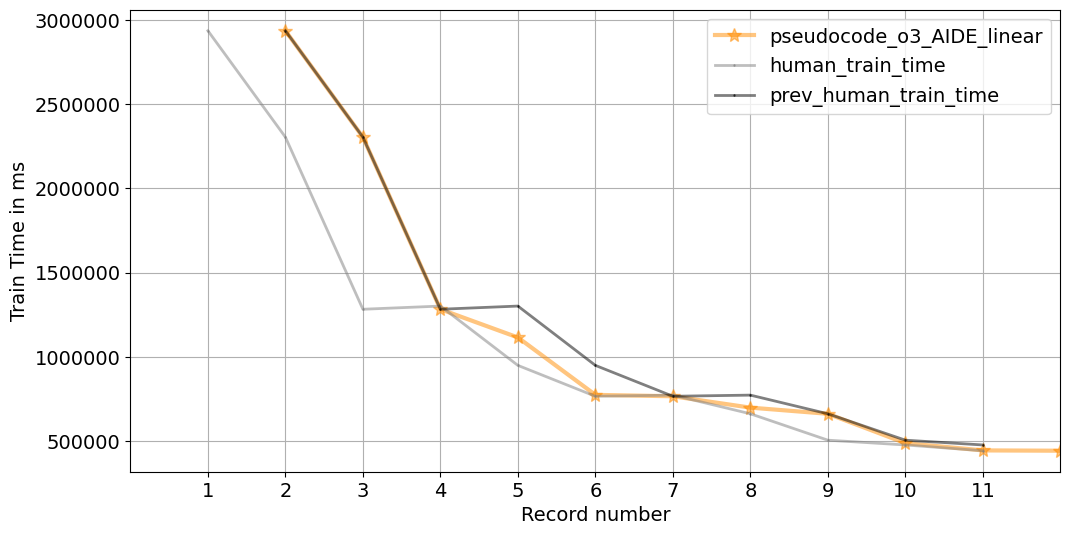

In [72]:
cmap = plt.get_cmap('tab10')
fig, ax = plt.subplots()
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items()}

# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)

# (r1_bon_gap_in_percentage, "R1 BON Gap Percentage", 'crimson'),
# (r1_aide_gap_in_percentage, "R1 AIDE Gap Percentage", 'royalblue'),
# (o3_bon_gap_in_percentage, "O3 BON Gap Percentage", 'forestgreen'),
# (o3_aide_gap_in_percentage, "O3 AIDE Gap Percentage", 'darkorange')


o3_aide_results_for_plot = {k + 1: v for k, v in sorted(o3_aide_results.items())}
# sorted_r1_bon_results = {k: v for k, v in sorted(r1_bon_results.items())}
ax.plot(o3_aide_results_for_plot.keys(), 
    o3_aide_results_for_plot.values(), 
    label='pseudocode_o3_AIDE_linear', 
    color='darkorange', linestyle='-', marker='*', markersize=10, linewidth=3, alpha=0.5)
ax.set_xlim(0, 12)
ax.set_xticks(range(1, 12))
ax.plot({k: v for k, v in human_train_time_dict.items() if 1 <= k <= 11}.keys(), 
    {k: v for k, v in human_train_time_dict.items() if 1 <= k <= 11}.values(), 
    label='human_train_time', 
    color=cmap(7), linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
prev_human_train_time_dict = {k + 1: v for k, v in human_train_time_dict.items() if 2 <= k + 1 <= 11}
ax.plot(prev_human_train_time_dict.keys(), prev_human_train_time_dict.values(), 
    label='prev_human_train_time', 
    color='black', linestyle='-', marker='d', markersize=1, linewidth=2, alpha=0.5)
ax.set_xlabel('Record number')
ax.set_ylabel('Train Time in ms')
ax.grid()
ax.legend()
def plain_formatter(x, pos):
    return f"{x:.0f}"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))

plt.show()